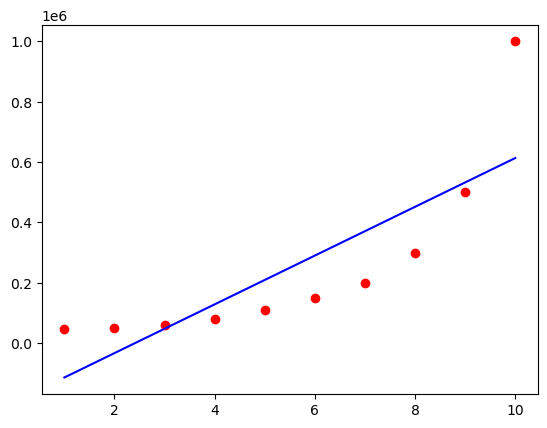

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv('Position_Salaries.csv')

# Bağımsız değişken (Seviye) ve Bağımlı değişken (Maaş)
X = df.iloc[:, 1:2].values 
y = df.iloc[:, 2].values   

#Linear Regression 
lin_reg = LinearRegression()
lin_reg.fit(X, y)

plt.scatter(X,y, color ='red')
plt.plot(X,lin_reg.predict(X),color='blue')
                        



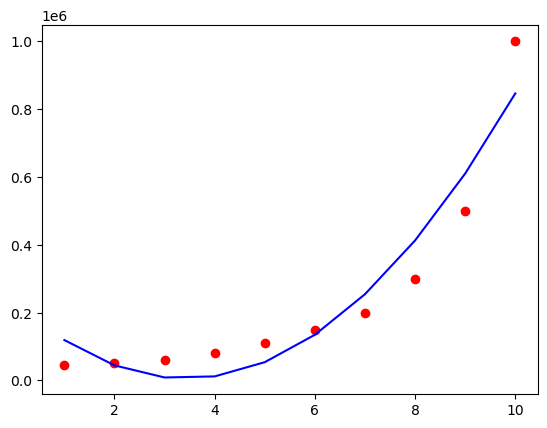

In [9]:
#Polynomial regression
#DEGREE=2
poly_reg = PolynomialFeatures(degree = 2)
x_poly = poly_reg.fit_transform(X)
lin_reg2 = LinearRegression()
lin_reg2.fit(x_poly,y)

plt.scatter(X,y,color ='red')
plt.plot(X,lin_reg2.predict(poly_reg.fit_transform(X)), color= 'blue')
plt.show()



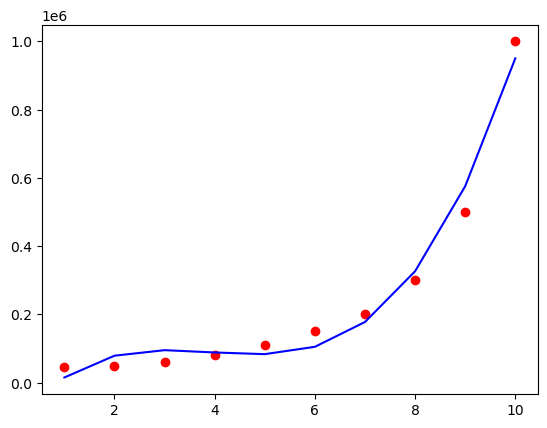

In [10]:
#Polynomial regression
#DEGREE=3
poly_reg = PolynomialFeatures(degree = 3 )
x_poly = poly_reg.fit_transform(X)
lin_reg3 = LinearRegression()
lin_reg3.fit(x_poly,y)

plt.scatter(X,y,color ='red')
plt.plot(X,lin_reg3.predict(poly_reg.fit_transform(X)), color= 'blue')
plt.show()

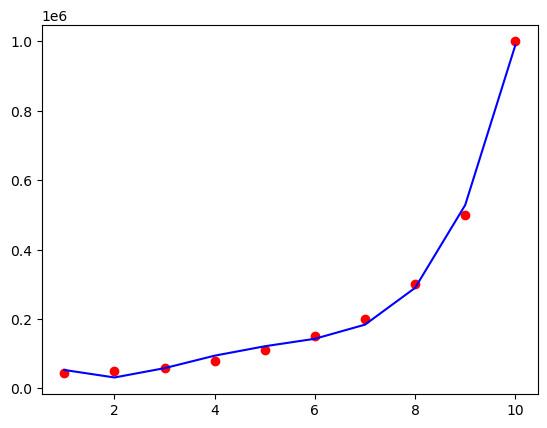

In [11]:
#Polynomial regression
#DEGREE=4
poly_reg = PolynomialFeatures(degree = 4)
x_poly = poly_reg.fit_transform(X)
lin_reg4 = LinearRegression()
lin_reg4.fit(x_poly,y)

plt.scatter(X,y,color ='red')
plt.plot(X,lin_reg4.predict(poly_reg.fit_transform(X)), color= 'blue')
plt.show()

In [12]:
print(lin_reg.predict([[6]]))

[289939.39393939]


In [13]:
print(lin_reg4.predict(poly_reg.fit_transform([[6]])))

[143275.05827509]


Mentor Soruları


Neden linear model başarısız oldu?

Çünkü veri (maaş hiyerarşisi) düz bir çizgi halinde artmıyor, yönetici seviyelerinde yukarı doğru keskin bir kavis çizerek fırlıyor. Linear model eğilemediği için veriyi ortadan ıskaladı (Underfitting).


Overfitting riski ne zaman başladı? 

Degree (derece) parametresini gereğinden fazla yükselttiğimizde başlar. Eğri o kadar fazla kıvrılır ki, mantıklı bir rota çizmek yerine sırf hatasız görünmek için tablodaki her bir noktaya zorla değmeye çalışır.


Degree fazla olursa ne olur?

Model genelleme yeteneğini kaybeder ve veriyi "ezberler" (Overfitting/Yüksek Varyans). Aradaki seviyeler (örneğin 6.5 seviyesi) sorulduğunda, gereksiz zikzaklar çizen bu eğri yüzünden tamamen mantıksız ve absürt maaş tahminleri (örneğin eksi değerler veya trilyonlar) üretebilir.

C:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


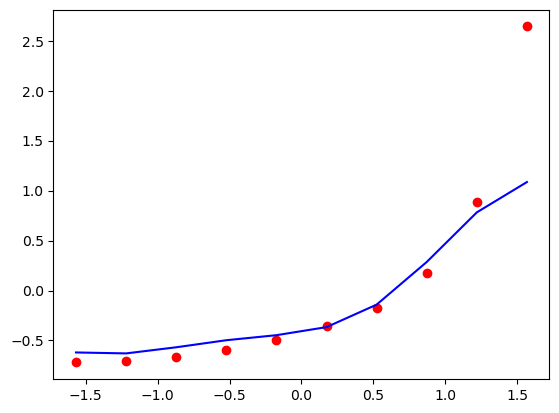

In [17]:
#Scaller
from sklearn.preprocessing import StandardScaler

sc1= StandardScaler()
x_scaler = sc1.fit_transform(X)

y_2d = y.reshape(-1, 1)
sc2= StandardScaler()
y_scaler = sc2.fit_transform(y_2d)

#SVR
from sklearn.svm import SVR

svr_reg = SVR(kernel ='rbf')
svr_reg.fit(x_scaler,y_scaler)

plt.scatter(x_scaler,y_scaler,color='red')
plt.plot(x_scaler,svr_reg.predict(x_scaler), color= 'blue')



Mentor Soruları

SVR neden farklı çalışıyor?

Klasik regresyonlar her bir veri noktasındaki hatayı (kalıntıyı) sıfıra indirmeye odaklanırken, SVR tamamen farklı bir strateji izler. SVR, tüm hataları yok etmeye çalışmak yerine kendine belirli bir "hata toleransı" belirler ve çizgisini sadece bu toleransın dışına taşan zorlu (aykırı) noktaları hesaplayarak şekillendirir.

    
Margin mantığı nedir?

Margin (Epsilon-Tube), SVR'nin çizdiği tahmin eğrisinin etrafındaki "güvenli bölge" tünelidir. Algoritma bu tüpün içinde kalan hataları (fiyat sapmalarını) tamamen görmezden gelir. Bu sayede model her ufak sarsıntıdan etkilenmez, genelleme yeteneği artar ve gürültülü (dalgalı) verilerde çok daha kararlı çalışır.

Feature scaling neden kritik?

Algoritmanın temeli uzaklık ölçümüne dayandığı için, milyonlarca doları ifade eden hedef (Target) değişkeninin, yüzlü sayılarla ifade edilen metrekare (Feature) değişkenini matematiksel olarak yutmasını/ezmesini engellemek için tüm verileri aynı matematiksel hizaya (scale) getirmek zorunludur.